# Cointegration Pairs Strategy — Research Notebook

Pair discovery, out-of-sample validation, walk-forward analysis, tearsheet,
and parameter sensitivity. Run top-to-bottom (`Kernel -> Restart & Run All`).

**Methodology in one paragraph.** The backtest runs over the full 2019–2023
window through an event-driven engine (point-in-time bars, next-bar fills,
commission + slippage). The strategy is dormant until `TRAIN_END`: on that
bar it screens pairs using only elapsed data — Engle–Granger on log prices
at p < 0.05 over the training window minus the final 3 months, then
re-qualification at p < 0.10 on those held-out 3 months. All trading and
all reported metrics are from bars **after** `TRAIN_END`, which the
discovery step never saw.

In [1]:
import sys; sys.path.insert(0, "..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

from run import run_backtest
from backtester.data import fetch_prices
from strategies.pairs import CointegrationPairsStrategy, SECTORS
from backtester.metrics import (
    sharpe_ratio, sortino_ratio, max_drawdown,
    annualized_return, WalkForwardRunner,
)
from backtester.tearsheet import plot_tearsheet

In [2]:
SYMBOLS = [s for sector in SECTORS.values() for s in sector]
START = "2019-01-01"
TRAIN_END = "2021-12-31"
END = "2023-12-31"
INITIAL_CAPITAL = 100_000.0

# One download, reused by every backtest below
PRICES = fetch_prices(SYMBOLS, START, "2024-01-01")
print(f"{len(SYMBOLS)} symbols, {len(PRICES[SYMBOLS[0]])} bars each")

25 symbols, 1258 bars each


## 1. Full backtest + pair discovery

One run over 2019–2023. The strategy discovers pairs at `TRAIN_END`
(2021-12-31) using only bars that have elapsed, then trades 2022–2023.

In [3]:
eq, strat = run_backtest(
    SYMBOLS, START, END,
    strategy_cls=CointegrationPairsStrategy,
    initial_capital=INITIAL_CAPITAL,
    strategy_kwargs={"train_end_date": TRAIN_END},
    preloaded=PRICES,
    return_strategy=True,
)

# Reproduce the discovery-time statistics for the qualified pairs
requal_start = pd.Timestamp(TRAIN_END) - pd.DateOffset(months=3)
rows = []
for a, b, beta in strat._pairs:
    la, lb = np.log(PRICES[a]["Close"]), np.log(PRICES[b]["Close"])
    _, p_in, _ = coint(la[la.index <= requal_start], lb[lb.index <= requal_start])
    rq = (la.index > requal_start) & (la.index <= pd.Timestamp(TRAIN_END))
    _, p_rq, _ = coint(la[rq], lb[rq])
    rows.append({
        "pair": f"{a}/{b}", "beta": round(beta, 3),
        "p_in_sample": round(p_in, 4), "p_requal": round(p_rq, 4),
    })
print(f"{len(strat._pairs)} pairs qualified (in-sample p<0.05, requal p<0.10):\n")
print(pd.DataFrame(rows).to_string(index=False))

4 pairs qualified (in-sample p<0.05, requal p<0.10):

     pair  beta  p_in_sample  p_requal
META/AVGO 0.924       0.0351    0.0160
 META/TXN 1.056       0.0221    0.0353
  BAC/PNC 0.889       0.0100    0.0169
  AXP/PNC 0.857       0.0103    0.0630


## 2. Out-of-sample performance (with costs)

Everything after `TRAIN_END` is out-of-sample: the discovery step never saw
these bars. Commission \$0.001/share and 5 bps slippage are always on.

In [4]:
eq_oos = eq[eq.index > pd.Timestamp(TRAIN_END)]
returns_oos = eq_oos["equity"].pct_change().dropna()
print(f"Out-of-sample Sharpe (with costs): {sharpe_ratio(returns_oos):.3f}")
print(f"Out-of-sample Sortino:             {sortino_ratio(returns_oos):.3f}")
print(f"Out-of-sample Max Drawdown:        {max_drawdown(eq_oos['equity']):.2%}")
print(f"Out-of-sample Ann. Return:         {annualized_return(eq_oos['equity']):.2%}")

Out-of-sample Sharpe (with costs): -1.254
Out-of-sample Sortino:             -0.835
Out-of-sample Max Drawdown:        -5.74%
Out-of-sample Ann. Return:         -2.63%


## 3. Cost drag

Same backtest with costs switched off, to quantify how much commission and
slippage matter. Many 'winning' strategies die here.

In [5]:
eq_nc = run_backtest(
    SYMBOLS, START, END,
    strategy_cls=CointegrationPairsStrategy,
    initial_capital=INITIAL_CAPITAL,
    commission=0.0, slippage_bps=0.0,
    strategy_kwargs={"train_end_date": TRAIN_END},
    preloaded=PRICES,
)
eq_nc_oos = eq_nc[eq_nc.index > pd.Timestamp(TRAIN_END)]
returns_nc = eq_nc_oos["equity"].pct_change().dropna()
print(f"OOS Sharpe (no costs): {sharpe_ratio(returns_nc):.3f}")
print(f"OOS Sharpe (w/ costs): {sharpe_ratio(returns_oos):.3f}")
print(f"Cost drag:             {sharpe_ratio(returns_nc) - sharpe_ratio(returns_oos):.3f} Sharpe points")

OOS Sharpe (no costs): -0.022
OOS Sharpe (w/ costs): -1.254
Cost drag:             1.232 Sharpe points


## 4. Tearsheet (out-of-sample, with costs)

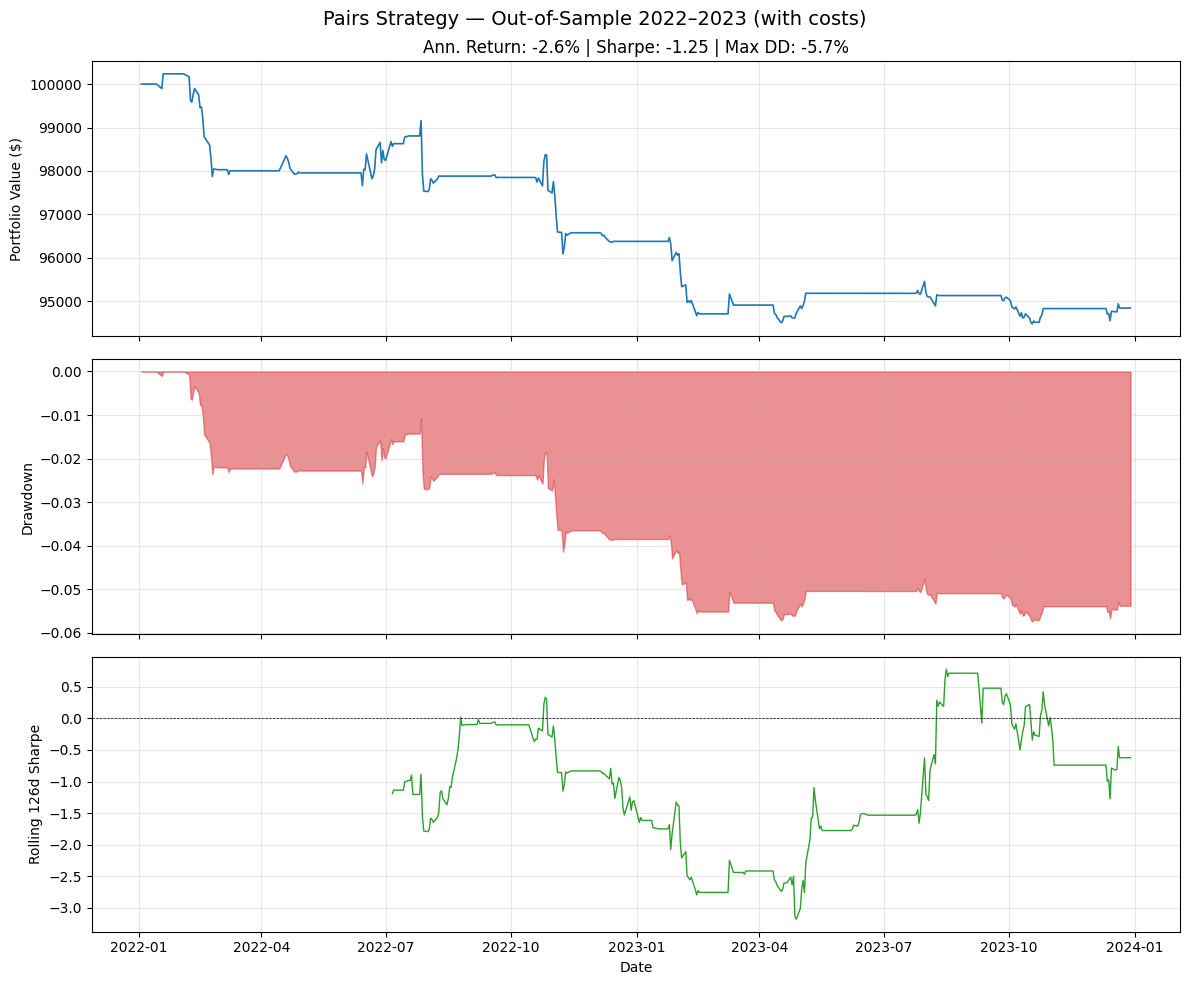

In [6]:
fig = plot_tearsheet(eq_oos, title="Pairs Strategy — Out-of-Sample 2022–2023 (with costs)")
plt.show()

## 5. Walk-forward analysis

Rolling 12-month train / 3-month test windows across 2019–2023. Each window
re-screens pairs from scratch on its own training data (9-month screen +
3-month requalification holdout) and trades only its test quarter.
`n_pairs = 0` means no pair passed the screen in that window — the
strategy stays flat rather than forcing trades.

In [7]:
def wf_run(train_start, train_end, test_start, test_end):
    eq_w, strat_w = run_backtest(
        SYMBOLS, train_start, test_end,
        strategy_cls=CointegrationPairsStrategy,
        initial_capital=INITIAL_CAPITAL,
        strategy_kwargs={"train_end_date": train_end},
        preloaded=PRICES,
        return_strategy=True,
    )
    test_eq = eq_w[eq_w.index > pd.Timestamp(train_end)]
    r = test_eq["equity"].pct_change().dropna()
    return {
        "n_pairs": len(strat_w._pairs),
        "sharpe": round(sharpe_ratio(r), 3),
        "max_dd": round(max_drawdown(test_eq["equity"]), 4),
        "ann_return": round(annualized_return(test_eq["equity"]), 4),
    }

runner = WalkForwardRunner(
    run_fn=wf_run,
    data_start=START,
    data_end=END,
    train_months=12,
    test_months=3,
)
wf_results = runner.run()

wf_df = pd.DataFrame([
    {
        "window": i + 1,
        "test_start": r["test_start"],
        "test_end": r["test_end"],
        "n_pairs": r["n_pairs"],
        "sharpe": r["sharpe"],
        "max_dd": r["max_dd"],
        "ann_return": r["ann_return"],
    }
    for i, r in enumerate(wf_results)
])
print(wf_df.to_string(index=False))
traded = wf_df[wf_df.n_pairs > 0]
print(f"\n{len(wf_df)} windows, {len(traded)} traded; "
      f"mean Sharpe across traded windows: {traded.sharpe.mean():.3f}")

 window test_start   test_end  n_pairs  sharpe  max_dd  ann_return
      1 2020-01-01 2020-04-01        4  -0.019 -0.0126     -0.0012
      2 2020-04-01 2020-07-01        0   0.000  0.0000      0.0000
      3 2020-07-01 2020-10-01        0   0.000  0.0000      0.0000
      4 2020-10-01 2021-01-01        0   0.000  0.0000      0.0000
      5 2021-01-01 2021-04-01        2  -1.425 -0.0049     -0.0089
      6 2021-04-01 2021-07-01        1   0.058 -0.0023      0.0003
      7 2021-07-01 2021-10-01        0   0.000  0.0000      0.0000
      8 2021-10-01 2022-01-01        0   0.000  0.0000      0.0000
      9 2022-01-01 2022-04-01        2  -0.271 -0.0083     -0.0038
     10 2022-04-01 2022-07-01        1   1.428 -0.0046      0.0334
     11 2022-07-01 2022-10-01        1   2.083 -0.0027      0.0321
     12 2022-10-01 2023-01-01        1   0.698 -0.0042      0.0103
     13 2023-01-01 2023-04-01        1  -0.127 -0.0090     -0.0045
     14 2023-04-01 2023-07-01        1  -1.696 -0.0062     -0.

## 6. Parameter sensitivity

Out-of-sample Sharpe across the entry/exit z-score grid. A robust strategy
degrades smoothly as thresholds move; a cliff means the headline number is
an artifact of one lucky parameter choice.

In [8]:
rows = []
for entry in (1.5, 2.0, 2.5):
    for exit_ in (0.0, 0.5, 1.0):
        eq_s = run_backtest(
            SYMBOLS, START, END,
            strategy_cls=CointegrationPairsStrategy,
            initial_capital=INITIAL_CAPITAL,
            strategy_kwargs={
                "train_end_date": TRAIN_END,
                "entry_z": entry,
                "exit_z": exit_,
            },
            preloaded=PRICES,
        )
        eq_s = eq_s[eq_s.index > pd.Timestamp(TRAIN_END)]
        r = eq_s["equity"].pct_change().dropna()
        rows.append({
            "entry_z": entry, "exit_z": exit_,
            "sharpe": round(sharpe_ratio(r), 3),
            "max_dd": round(max_drawdown(eq_s["equity"]), 4),
        })

sens_df = pd.DataFrame(rows)
print("OOS Sharpe by entry/exit z-score:\n")
print(sens_df.pivot(index="entry_z", columns="exit_z", values="sharpe"))

OOS Sharpe by entry/exit z-score:

exit_z     0.0    0.5    1.0
entry_z                     
1.5     -1.707 -1.710 -1.432
2.0     -1.254 -1.254 -1.293
2.5     -1.226 -1.226 -1.226


## 7. Reading the results honestly

The numbers above are what they are — they were **not** tuned until they
looked good. Points to take away:

- **Costs are the headline.** Gross of costs the strategy is roughly flat
  (Sharpe ≈ 0); commission and slippage turn it clearly negative, costing
  over a full Sharpe point. The stop-out rule (exit when rolling
  cointegration breaks, p > 0.1) limits losses from broken pairs but
  generates churn that the cost model punishes. This is the classic
  failure mode the engine exists to expose: a strategy that looks harmless
  gross can be unviable net.
- **Regime dependence is visible.** The walk-forward table shows the
  strategy idle in several windows (no pair passes the screen — it stays
  flat rather than forcing trades) and uneven performance across traded
  windows. Several discovered pairs include META, whose idiosyncratic 2022
  collapse broke its cointegrating relationships outright.
- **No lucky parameters.** The sensitivity grid is smooth and uniformly
  negative — the headline number is not an artifact of one threshold
  choice.
- **A negative out-of-sample result reported in full is the point of the
  exercise.** The engine prevents look-ahead structurally; the validation
  pipeline (held-out requalification, walk-forward, sensitivity grid)
  measures the strategy rather than flattering it.